## ML + DL 분리 피처 전략 vD-2

In [1]:
# 변경사항:
#  - SHAP 누적 95% 기준으로 ML과 DL 동일하게 Top66 사용
#  - LGB split 기준에서 과소평가됐던 이진형 피처들(이식수_최적, 시술 유형, 정확히_D5, 기증_사용 등)이 Top66 안에 포함됨
#  - ML·DL 피처셋이 같아서 두 모델이 동일한 정보를 공유 → 스태킹 다양성은 vD-3보다 낮을 수 있음

# 실험 로그

| 실험 | 모델 | Feature Engineering | 파라미터 | Score | 비고 | 리더보드 점수 |
|------|------|---------------------|----------|-------|------|------|
| 4/24(금)|
| exp0 | LightGBM | 기본 feature + 파생변수 110개 | C=1.0, max_iter=100 | 0.7385 | | 리더보드 점수 : 0.5 |
| exp1 | XGBoost | 기본 feature + 파생변수 110개 | lr=0.05, depth=6, subsample=0.8 | 0.7392 | | 리더보드 점수 : 0.5|
| exp2 | Catboost | - | iterations=2000, lr=0.05, depth=6 | 0.7397 | | 리더보드 점수 : 0.7412 |
| exp3 | XGBoost x Catboost 앙상블 | 기본 feature + 파생변수 110개 | iterations=2000, lr=0.05, depth=6  | 0.7399 | A. Simple Average (XGB : Cat = 1:1) |
| exp4 | - |  -  |  - | 0.7399 | B. Weighted Average(OOF AUC가 높은 모델 가중치 부여) |
| exp5 | - |  -  |  - | 0.7399 | C. Stacking (메타 모델 : LR) |
| exp6 | - |  -  |  - | 0.7399 | D. Rank Average(확률 대신 순위로 변환 후 평균) |
| exp7 | XGBoost | 기본 feature + 파생변수 110개 | XGB: depth=5 / Cat: depth=5  | 0.7397 |optuna|
| exp8 | Catboost | - | XGB: depth=5 / Cat: depth=5  | 0.7397 |optuna |
| exp7 | XGBoost x Catboost 앙상블(optuna) |  기본 feature + 파생변수 110개  | XGB: depth=5 / Cat: depth=5 | 0.7399 | A. Simple Average (XGB : Cat = 1:1) |
| exp8 | - |  -  |  - | 0.7399 | B. Weighted Average(OOF AUC가 높은 모델 가중치 부여) |
| exp9 | - |  -  |  - | 0.7399 | C. Stacking (메타 모델 : LR) |
| exp10 | - |  -  |  - | 0.7399 | D. Rank Average(확률 대신 순위로 변환 후 평균) | 리더보드 점수 : 0.74162 |
| 4/25(토) |
| exp11 | LGBM x XGBoost x Catboost 앙상블(optuna) |  기본 feature + 파생변수 110개  | LGBM : max_depth=3 / XGB: max_depth=5 / Cat: depth=6 | 0.7400 | |리더보드 점수 :  0.74140  |
| 4/26(일)|
| exp12 | XGBoost + CatBoost + LightGBM + RandomForest + ExtraTree 앙상블(optuna) |  기본 feature + 파생변수 110개  | LGBM : max_depth=3 / XGB: max_depth=5 / Cat: depth=6 | 0.7398 | Stacking (메타모델 : LR) |
| exp13 | XGBoost + CatBoost + LightGBM 앙상블(파생변수 추가) |  기본 feature + 파생변수 110개 + 신규 파생변수 29  | - | 0.73788 | |
| exp14 | seed 앙상블(파생변수 추가) |  기본 feature + 파생변수 110개 + 신규 파생변수 29  | - | 0.73998 | | 리더보드 점수 : 0.74182 |
| 4/27(월)|
| exp15 | seed 앙상블 + 딥러닝(TabNet + FT-Transformer ) |  기본 feature + 파생변수 110개 + 신규 파생변수 29  | - | 0.73970 | 2단계 스태킹 앙상블 |
| exp16 | ML + DL(TabNet + MLP + FT-Transformer) feature split |  기본 feature + 파생변수 110개 + 신규 파생변수 29 + 결측치로 제거했던 컬럼 6개 복구 | - |  | feature split |  |
| exp17 | ML + DL(TabNet + MLP + FT-Transformer) feature split |  기본 feature + 파생변수 110개 + 신규 파생변수 29 + 결측치로 제거했던 컬럼 6개 복구 + 시술 시기 코드 컬럼 파생변수 5개 | - | 0.74058 | feature split | 리더보드 점수 : 0.74183 |
| exp18 | ML + DL(MLP + FT-Transformer) feature split |  기본 feature + 파생변수 110개 + 신규 파생변수 29 + 결측치로 제거했던 컬럼 6개 복구 + 시술 시기 코드 컬럼 파생변수 5개 | - | 0.74047 | TabNet 제거 -> 결론 : 포함되어야 함 |  |
| 4/28(화)|
| exp19 | ML + DL(TabNet + MLP + FT-Transformer) feature split |  기본 feature + 파생변수 110개 + 신규 파생변수 29 + 결측치로 제거했던 컬럼 6개 복구 + 시술 시기 코드 컬럼 파생변수 5개 + 파생변수 6개 추가 | - | 0.74053 | HistGradientBoosting추가 -> 결론 : 제거하기|  |
| exp20 | ML + DL(TabNet + MLP + FT-Transformer) feature split |  기본 feature + 파생변수 110개 + 신규 파생변수 29 + 결측치로 제거했던 컬럼 6개 복구 + 시술 시기 코드 컬럼 파생변수 5개 + 파생변수 6개 추가 | - | 0.74052 | ML 피처셋Top 65, DL 피처셋Top 85|  |
| exp21 | ML + DL(TabNet + MLP + FT-Transformer) feature split |  기본 feature + 파생변수 110개 + 신규 파생변수 29 + 결측치로 제거했던 컬럼 6개 복구 + 시술 시기 코드 컬럼 파생변수 5개 + 파생변수 6개 추가 | - | 0.74065 | ML 피처셋Top 65, DL 피처셋 중요도 >0|  |
| exp22 | ML + DL(TabNet + MLP + FT-Transformer) feature split |  기본 feature + 파생변수 110개 + 신규 파생변수 29 + 결측치로 제거했던 컬럼 6개 복구 + 시술 시기 코드 컬럼 파생변수 5개 + 파생변수 6개 추가 | - | 0.74076  | shrp feature 중요도 분석, 150개 전체 피처 사용(SHAP)|  |
| exp23 | ML + DL(TabNet + MLP + FT-Transformer) feature split |  기본 feature + 파생변수 110개 + 신규 파생변수 29 + 결측치로 제거했던 컬럼 6개 복구 + 시술 시기 코드 컬럼 파생변수 5개 + 파생변수 6개 추가 | - | 0.74026 | SHAP 누적 95% 기준으로 ML과 DL 동일하게 Top66 |  |

## 0. 패키지 설치 및 임포트

In [ ]:
! pip install -q catboost lightgbm xgboost optuna pytorch-tabnet koreanize-matplotlib

import warnings, os, json
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.optimize import minimize

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import HistGradientBoostingClassifier   # ★ 추가

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    import koreanize_matplotlib
except:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42
N_SPLITS     = 5
N_OPTUNA     = 30
np.random.seed(RANDOM_STATE)

# GPU 설정
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

TARGET   = "임신 성공 여부"
ID_COL   = "ID"
DATA_DIR = Path(".")

train = pd.read_csv('/kaggle/input/datasets/chmin0207/infertility-patient-data/train.csv', encoding="utf-8-sig")
test  = pd.read_csv('/kaggle/input/datasets/chmin0207/infertility-patient-data/test.csv',  encoding="utf-8-sig")
sub   = pd.read_csv('/kaggle/input/datasets/chmin0207/infertility-patient-data/sample_submission.csv', encoding="utf-8-sig")
train.columns = [c.strip() for c in train.columns]
test.columns  = [c.strip() for c in test.columns]
print(f"Train: {train.shape} | Test: {test.shape}")
print(f"양성 비율: {train[TARGET].mean():.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 62.2 MB/s eta 0:00:0000:0100:01
Device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB
Train: (256351, 69) | Test: (90067, 68)
양성 비율: 0.2583


## 1. 인코딩 맵 & 전처리 상수

In [3]:
AGE_MAP       = {"만18-34세":0,"만35-37세":1,"만38-39세":2,"만40-42세":3,"만43-44세":4,"만45-50세":5,"알 수 없음":-1}
COUNT_MAP     = {"0회":0,"1회":1,"2회":2,"3회":3,"4회":4,"5회":5,"6회 이상":6}
DONOR_AGE_MAP = {"만20세 이하":0,"만21-25세":1,"만26-30세":2,"만31-35세":3,"만36-40세":4,"만41-45세":5,"알 수 없음":-1}
INDUCTION_MAP = {"알 수 없음":0,"기록되지 않은 시행":1,"생식선 자극 호르몬":2,"세트로타이드 (억제제)":3}
EGG_MAP       = {"본인 제공":0,"기증 제공":1,"알 수 없음":-1}
SPERM_MAP     = {"배우자 제공":0,"기증 제공":1,"배우자 및 기증 제공":2,"미할당":-1}
COUNT_COLS    = ["총 시술 횟수","클리닉 내 총 시술 횟수","IVF 시술 횟수","DI 시술 횟수",
                 "총 임신 횟수","IVF 임신 횟수","DI 임신 횟수","총 출산 횟수","IVF 출산 횟수","DI 출산 횟수"]
DROP_COLS     = []
REASON_CATS   = ["현재 시술용","배아 저장용","난자 저장용","기증용","연구용"]
PROC_TYPES    = ["IVF","ICSI","IUI","ICI","GIFT","FER","BLASTOCYST","AH","Generic DI","IVI"]

# 시술 시기 코드 파생변수 고정 맵 (train 통계 → test transform only)
CODE_D5_RATE   = {"TRDQAZ":0.376,"TRCMWS":0.365,"TRYBLT":0.357,"TRJXFG":0.339,"TRVNRY":0.301,"TRZKPL":0.256,"TRXQMD":0.217}
CODE_D3_RATE   = {"TRDQAZ":0.147,"TRCMWS":0.174,"TRYBLT":0.205,"TRJXFG":0.231,"TRVNRY":0.256,"TRZKPL":0.287,"TRXQMD":0.295}
CODE_TIME_ORDER= {"TRXQMD":0,"TRZKPL":1,"TRVNRY":2,"TRJXFG":3,"TRYBLT":4,"TRCMWS":5,"TRDQAZ":6}
CODE_SUCCESS   = {"TRDQAZ":0.245,"TRCMWS":0.257,"TRYBLT":0.269,"TRJXFG":0.266,"TRVNRY":0.260,"TRZKPL":0.255,"TRXQMD":0.256}

print("상수 설정 완료")

# Optuna 캐시 파라미터
USE_CACHED_PARAMS = True

CACHED_XGB = {
    "n_estimators":1800, "learning_rate":0.01681590206217679,
    "max_depth":6, "subsample":0.7219206134659216,
    "colsample_bytree":0.6872602657464894, "reg_alpha":7.452848201378795,
    "reg_lambda":9.211281496853013, "min_child_weight":9,
    "gamma":4.14379616379793, "scale_pos_weight":2.064196846705621,
}
CACHED_CAT = {
    "iterations":1200, "learning_rate":0.02441661265474018,
    "depth":7, "l2_leaf_reg":7.790676508309964,
    "bagging_temperature":1.0157813933009723,
    "random_strength":1.1252522473159237, "border_count":91,
}
CACHED_LGB = {
    "n_estimators":1300, "learning_rate":0.020263188298172464,
    "num_leaves":150, "max_depth":4,
    "subsample":0.91206952631544, "colsample_bytree":0.9428380005720536,
    "reg_alpha":0.9061803492912888, "reg_lambda":3.7279273338107584,
    "min_child_samples":100, "boosting_type":"gbdt",
}
# ★ HistGBM 파라미터 (sklearn 기본값 기반)
CACHED_HGB = {
    "max_iter":1000, "learning_rate":0.05, "max_depth":6,
    "min_samples_leaf":50, "l2_regularization":1.0,
    "max_bins":255, "class_weight":"balanced",
}

상수 설정 완료


## 2. 전처리 함수

In [4]:
def expand_reason(df):
    for cat in REASON_CATS:
        df[f"이유_{cat}"] = df["배아 생성 주요 이유"].fillna("").str.contains(cat).astype(int)
    return df

def expand_procedure(df):
    filled = df["특정 시술 유형"].fillna("Unknown")
    for pt in PROC_TYPES:
        df[f"시술_{pt}"] = filled.str.upper().str.replace(" ", "", regex=False).str.contains(pt.upper()).astype(int)
    return df

def preprocess(df, medians=None, fit=False):
    df = df.copy()
    for col in ["착상 전 유전 검사 사용 여부","PGD 시술 여부","PGS 시술 여부"]:
        if col in df.columns: df[col] = df[col].notna().astype(int)
    if "난자 채취 경과일" in df.columns:
        df["난자_채취_결측"] = df["난자 채취 경과일"].isnull().astype(int)
        df["난자 채취 경과일"] = df["난자 채취 경과일"].fillna(0)
    if "배아 해동 경과일" in df.columns:
        df["배아_해동_결측"] = df["배아 해동 경과일"].isnull().astype(int)
        df["배아 해동 경과일"] = df["배아 해동 경과일"].fillna(0)
    col_y = "임신 시도 또는 마지막 임신 경과 연수"
    if col_y in df.columns:
        df["임신_시도_연수_결측"] = df[col_y].isnull().astype(int)
        df[col_y] = df[col_y].fillna(-1)
    fill_zero = ["단일 배아 이식 여부","착상 전 유전 진단 사용 여부","총 생성 배아 수",
                 "미세주입된 난자 수","미세주입에서 생성된 배아 수","이식된 배아 수",
                 "미세주입 배아 이식 수","저장된 배아 수","미세주입 후 저장된 배아 수",
                 "해동된 배아 수","해동 난자 수","수집된 신선 난자 수","저장된 신선 난자 수",
                 "혼합된 난자 수","파트너 정자와 혼합된 난자 수","기증자 정자와 혼합된 난자 수",
                 "동결 배아 사용 여부","신선 배아 사용 여부","기증 배아 사용 여부","대리모 여부"]
    for c in fill_zero:
        if c in df.columns: df[c] = df[c].fillna(0)
    if medians is None: medians = {}
    for col in ["난자 혼합 경과일","배아 이식 경과일"]:
        if col not in df.columns: continue
        if fit: medians[col] = df[col].median()
        df[col] = df[col].fillna(medians.get(col, 0))
    cont_cols = ["총 생성 배아 수","미세주입된 난자 수","미세주입에서 생성된 배아 수",
                 "이식된 배아 수","미세주입 배아 이식 수","저장된 배아 수",
                 "미세주입 후 저장된 배아 수","해동된 배아 수","해동 난자 수",
                 "수집된 신선 난자 수","저장된 신선 난자 수","혼합된 난자 수",
                 "파트너 정자와 혼합된 난자 수","기증자 정자와 혼합된 난자 수","배아 해동 경과일"]
    for c in cont_cols:
        if c not in df.columns: continue
        df[c] = pd.to_numeric(df[c], errors="coerce")
        if fit: medians[c] = df[c].median() if df[c].notna().any() else 0
        df[c] = df[c].fillna(medians.get(c, 0))
    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(AGE_MAP).fillna(-1).astype(int)
    for col in COUNT_COLS:
        if col in df.columns: df[col] = df[col].map(COUNT_MAP).fillna(-1).astype(int)
    for col in ["난자 기증자 나이","정자 기증자 나이"]:
        if col in df.columns: df[col] = df[col].map(DONOR_AGE_MAP).fillna(-1).astype(int)
    if "시술 유형" in df.columns:     df["시술 유형"] = (df["시술 유형"] == "IVF").astype(int)
    if "배란 유도 유형" in df.columns: df["배란 유도 유형"] = df["배란 유도 유형"].map(INDUCTION_MAP).fillna(0).astype(int)
    if "난자 출처" in df.columns:     df["난자 출처"] = df["난자 출처"].map(EGG_MAP).fillna(-1).astype(int)
    if "정자 출처" in df.columns:     df["정자 출처"] = df["정자 출처"].map(SPERM_MAP).fillna(-1).astype(int)
    if "시술 시기 코드" in df.columns:
        cs = df["시술 시기 코드"].copy()
        df["코드_D5비율"]    = cs.map(CODE_D5_RATE).fillna(0)
        df["코드_D3비율"]    = cs.map(CODE_D3_RATE).fillna(0)
        df["코드_시간순서"]  = cs.map(CODE_TIME_ORDER).fillna(3)
        df["코드_성공률"]    = cs.map(CODE_SUCCESS).fillna(0)
        age_n = df["시술 당시 나이"].replace(-1, 0).clip(lower=0)
        df["코드_시간x나이"] = df["코드_시간순서"] * age_n
        df.drop(columns=["시술 시기 코드"], inplace=True)
    binary_cols = ["배란 자극 여부","단일 배아 이식 여부","착상 전 유전 진단 사용 여부",
                   "남성 주 불임 원인","남성 부 불임 원인","여성 주 불임 원인","여성 부 불임 원인",
                   "부부 주 불임 원인","부부 부 불임 원인","불명확 불임 원인",
                   "불임 원인 - 난관 질환","불임 원인 - 남성 요인","불임 원인 - 배란 장애",
                   "불임 원인 - 자궁경부 문제","불임 원인 - 자궁내막증","불임 원인 - 여성 요인",
                   "불임 원인 - 정자 농도","불임 원인 - 정자 면역학적 요인",
                   "불임 원인 - 정자 운동성","불임 원인 - 정자 형태",
                   "동결 배아 사용 여부","신선 배아 사용 여부","기증 배아 사용 여부","대리모 여부"]
    for c in binary_cols:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)
    return df, medians

## 3. 파생변수 함수

In [5]:
def feature_engineering(df):
    df = df.copy()
    for c in ["총 생성 배아 수","이식된 배아 수","저장된 배아 수","수집된 신선 난자 수",
              "미세주입에서 생성된 배아 수","미세주입된 난자 수","해동된 배아 수",
              "미세주입 후 저장된 배아 수","총 임신 횟수","총 시술 횟수",
              "클리닉 내 총 시술 횟수","IVF 시술 횟수","동결 배아 사용 여부",
              "신선 배아 사용 여부","기증 배아 사용 여부","시술 유형","시술 당시 나이"]:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
    cause_cols = [c for c in df.columns if "불임 원인 -" in c]
    df["불임_원인_합계"]      = df[cause_cols].sum(axis=1)
    primary = [c for c in ["남성 주 불임 원인","여성 주 불임 원인","부부 주 불임 원인"] if c in df.columns]
    df["주요_불임_원인_합계"] = df[primary].sum(axis=1)
    df["이식_효율"]  = np.where(df["총 생성 배아 수"]>0, df["이식된 배아 수"]/df["총 생성 배아 수"], 0)
    df["ICSI_비율"]  = np.where(df["총 생성 배아 수"]>0, df["미세주입에서 생성된 배아 수"]/df["총 생성 배아 수"], 0)
    df["과거_임신_성공률"] = np.where(df["총 시술 횟수"]>0, df["총 임신 횟수"]/(df["총 시술 횟수"]+1), 0)
    for col in ["동결 배아 사용 여부","신선 배아 사용 여부","기증 배아 사용 여부"]:
        if col not in df.columns: df[col] = 0
    df["배아_전략"]  = df["동결 배아 사용 여부"]*1 + df["신선 배아 사용 여부"]*0 + df["기증 배아 사용 여부"]*2
    df["저장_비율"]  = np.where(df["총 생성 배아 수"]>0, df["저장된 배아 수"]/df["총 생성 배아 수"], 0)
    df["기증_사용"]  = ((df.get("난자 출처", pd.Series(0,index=df.index))==1) |
                        (df.get("정자 출처", pd.Series(0,index=df.index))==1)).astype(int)
    if "해동된 배아 수" in df.columns:
        df["동결배아_활용률"]    = np.where(df["저장된 배아 수"]>0, df["해동된 배아 수"]/df["저장된 배아 수"], 0)
        df["ICSI동결_이식비율"]  = np.where(df["이식된 배아 수"]>0, df["미세주입 후 저장된 배아 수"]/df["이식된 배아 수"], 0)
        df["순수동결_주기"]      = ((df["동결 배아 사용 여부"]==1)&(df["신선 배아 사용 여부"]==0)).astype(int)
        remaining = (df["저장된 배아 수"] - df["해동된 배아 수"]).clip(lower=0)
        df["동결배아_잉여율"]    = np.where(df["저장된 배아 수"]>0, remaining/df["저장된 배아 수"], 0)
        df["동결배아_총량"]      = df["저장된 배아 수"] + df["해동된 배아 수"]
    if "수집된 신선 난자 수" in df.columns:
        age_num = df["시술 당시 나이"].replace(-1, np.nan)
        egg_cnt = df["수집된 신선 난자 수"]
        df["나이x난자수"]       = (age_num * egg_cnt).fillna(0)
        df["나이보정_난자효율"] = egg_cnt / (age_num.fillna(0) + 1)
        df["고령저반응"]        = ((age_num>=3) & (egg_cnt<egg_cnt.median())).fillna(False).astype(int)
        df["젊고고수확"]        = ((age_num<=1) & (egg_cnt>=egg_cnt.quantile(0.75))).fillna(False).astype(int)
    df["배아_손실수"]    = (df["총 생성 배아 수"] - df["이식된 배아 수"] - df["저장된 배아 수"]).clip(lower=0)
    df["배아_총활용률"]  = np.where(df["총 생성 배아 수"]>0,
                                    (df["이식된 배아 수"]+df["저장된 배아 수"])/df["총 생성 배아 수"], 0).clip(0,1)
    emax = max(df["총 생성 배아 수"].max()+1, 9)
    df["배아_풍요도"]    = pd.cut(df["총 생성 배아 수"], bins=[-1,0,3,7,emax], labels=[0,1,2,3]).astype(float).fillna(0).astype(int)
    df["다배아이식_플래그"]    = (df["이식된 배아 수"]>=3).astype(int)
    df["ICSI배아_우위비율"]    = np.where(df["총 생성 배아 수"]>0, df["미세주입에서 생성된 배아 수"]/df["총 생성 배아 수"], 0)
    denom = df["이식된 배아 수"] + df["저장된 배아 수"]
    df["이식_집중도"]    = np.where(denom>0, df["이식된 배아 수"]/denom, 0)
    if "시술 유형" in df.columns:
        age2 = df["시술 당시 나이"].replace(-1, 0)
        df["나이x시술유형"]     = age2 * df["시술 유형"]
        df["고령IVF"]           = ((df["시술 당시 나이"]>=3) & (df["시술 유형"]==1)).astype(int)
        df["젊은DI"]            = ((df["시술 당시 나이"]<=1) & (df["시술 유형"]==0)).astype(int)
        df["나이_시술_복합코드"] = df["시술 당시 나이"].clip(lower=0)*10 + df["시술 유형"]
    if "총 시술 횟수" in df.columns:
        age3  = df["시술 당시 나이"].replace(-1, 0)
        trial = df["총 시술 횟수"].replace(-1, 0)
        df["나이x총시술횟수"]     = age3 * trial
        df["나이x클리닉시술횟수"] = age3 * df["클리닉 내 총 시술 횟수"].replace(-1, 0)
        ivf = df["IVF 시술 횟수"].replace(-1, 0)
        df["나이xIVF횟수"]   = age3 * ivf
        df["시술부담_지수"]  = age3 * (trial + ivf) / 2
        df["고령반복시술"]   = ((df["시술 당시 나이"]>=3) & (trial>=3)).astype(int)
    return df

def add_embryo_quality_features(df):
    out = df.copy()
    for c in ["총 생성 배아 수","수집된 신선 난자 수","미세주입에서 생성된 배아 수","미세주입된 난자 수","이식된 배아 수"]:
        if c in out.columns: out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0)
    if "배아 이식 경과일" in out.columns:
        out["배아 이식 경과일"] = pd.to_numeric(out["배아 이식 경과일"], errors="coerce")
    out["수정률"]      = np.where(out["수집된 신선 난자 수"]>0,
                                  out["총 생성 배아 수"]/out["수집된 신선 난자 수"], np.nan).clip(0,1)
    out["수정률_결측"] = (out["수집된 신선 난자 수"]==0).astype(int)
    out["수정률"]      = out["수정률"].fillna(0)
    out["수정률_양호"] = (out["수정률"]>=0.5).astype(int)
    out["수정률_구간"] = pd.cut(out["수정률"], bins=[-0.01,0.3,0.5,0.7,1.01], labels=[0,1,2,3]).astype(float)
    out["is_D5"]       = np.where(out["배아 이식 경과일"].isnull(), np.nan,
                                  (out["배아 이식 경과일"]>=5).astype(float))
    out["D5_결측"]     = out["배아 이식 경과일"].isnull().astype(int)
    out["is_D5"]       = out["is_D5"].fillna(0)
    out["이식단계"]    = np.where(out["배아 이식 경과일"].isnull(), -1,
                                  np.where(out["배아 이식 경과일"]<=3, 0,
                                  np.where(out["배아 이식 경과일"]>=5, 1, 0)))
    out["ICSI수정률"]  = np.where(out["미세주입된 난자 수"]>0,
                                  out["미세주입에서 생성된 배아 수"]/out["미세주입된 난자 수"], np.nan).clip(0,1)
    out["ICSI_미시행"] = (out["미세주입된 난자 수"]==0).astype(int)
    out["ICSI수정률"]  = out["ICSI수정률"].fillna(0)
    out["ICSI수정률_양호"] = (out["ICSI수정률"]>=0.7).astype(int)
    out["ICSI수정률_구간"] = pd.cut(out["ICSI수정률"], bins=[-0.01,0.5,0.7,0.9,1.01], labels=[0,1,2,3]).astype(float)
    out["이식수_최적"]  = out["이식된 배아 수"].isin([1.0,2.0]).astype(int)
    out["최적이식_D5"] = out["이식수_최적"] * out["is_D5"]
    out["배아질_복합"] = out["수정률"].clip(0,1)*0.4 + out["is_D5"]*0.4 + out["이식수_최적"]*0.2
    return out

def add_new_features(df):
    out = df.copy()
    for c in ["총 생성 배아 수","이식된 배아 수","저장된 배아 수","수집된 신선 난자 수",
              "저장된 신선 난자 수","혼합된 난자 수","해동된 배아 수","파트너 정자와 혼합된 난자 수",
              "배아 이식 경과일","난자 혼합 경과일","시술 당시 나이","시술 유형",
              "총 시술 횟수","클리닉 내 총 시술 횟수","IVF 시술 횟수",
              "총 임신 횟수","총 출산 횟수","IVF 임신 횟수","IVF 출산 횟수",
              "DI 임신 횟수","DI 출산 횟수","미세주입된 난자 수","미세주입에서 생성된 배아 수"]:
        if c in out.columns: out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0)
    fert = np.where(out["수집된 신선 난자 수"]>0,
                    out["총 생성 배아 수"]/out["수집된 신선 난자 수"], 0).clip(0,1)
    # 그룹 A. 배아 이식 경과일
    out["혼합_이식_간격"]    = (out["배아 이식 경과일"] - out["난자 혼합 경과일"]).fillna(0)
    out["이식일_D5이상"]     = (out["배아 이식 경과일"]>=5).fillna(False).astype(int)
    out["이식일x이식수"]     = out["배아 이식 경과일"].fillna(0) * out["이식된 배아 수"].fillna(0)
    out["이식일_결측"]       = (out["배아 이식 경과일"]==0).astype(int)
    out["정확히_D5"]         = (out["배아 이식 경과일"]==5.0).astype(int)
    out["D5_최적이식_복합"]  = ((out["배아 이식 경과일"]>=5) &
                                 (out["이식된 배아 수"].isin([1.0,2.0]))).fillna(False).astype(int)
    # 그룹 B. 배아/난자 품질
    out["생성배아_품질복합"] = out["총 생성 배아 수"] * fert
    out["난자_풍부도"]       = pd.cut(out["수집된 신선 난자 수"], bins=[-1,0,4,8,12,999],
                                      labels=[0,1,2,3,4]).astype(float).fillna(0).astype(int)
    out["신선난자_저장비율"] = np.where(out["수집된 신선 난자 수"]>0,
                                        out["저장된 신선 난자 수"]/out["수집된 신선 난자 수"], 0)
    out["파트너정자_활용률"] = np.where(out["혼합된 난자 수"]>0,
                                        out["파트너 정자와 혼합된 난자 수"]/out["혼합된 난자 수"], 0)
    out["전체_배아_효율"]    = np.where(out["수집된 신선 난자 수"]>0,
                                        (out["이식된 배아 수"]+out["저장된 배아 수"])/out["수집된 신선 난자 수"], 0).clip(0,5)
    # 그룹 C. 시술 이력
    out["초회시술"]          = (out["총 시술 횟수"]==0).astype(int)
    out["초회IVF"]           = ((out["IVF 시술 횟수"]==0) & (out["총 시술 횟수"]<=1)).astype(int)
    out["클리닉_집중도"]     = np.where(out["총 시술 횟수"]>0,
                                        out["클리닉 내 총 시술 횟수"]/out["총 시술 횟수"], 1.0).clip(0,1)
    out["IVF_임신_전환율"]   = np.where(out["IVF 시술 횟수"]>0,
                                        out["IVF 임신 횟수"]/out["IVF 시술 횟수"], 0).clip(0,1)
    out["임신_출산_전환율"]  = np.where(out["총 임신 횟수"]>0,
                                        out["총 출산 횟수"]/out["총 임신 횟수"], 0).clip(0,1)
    out["출산_경험"]         = (out["총 출산 횟수"]>0).astype(int)
    out["IVF_출산_경험"]     = (out["IVF 출산 횟수"]>0).astype(int)
    # 그룹 D. 불임 원인
    mc = [c for c in ["남성 주 불임 원인","남성 부 불임 원인","불임 원인 - 남성 요인",
                       "불임 원인 - 정자 농도","불임 원인 - 정자 운동성","불임 원인 - 정자 형태",
                       "불임 원인 - 정자 면역학적 요인"] if c in out.columns]
    fc = [c for c in ["여성 주 불임 원인","여성 부 불임 원인","불임 원인 - 난관 질환",
                       "불임 원인 - 배란 장애","불임 원인 - 자궁내막증","불임 원인 - 자궁경부 문제"] if c in out.columns]
    out["남성불임_복합"] = out[mc].fillna(0).sum(axis=1)
    out["여성불임_복합"] = out[fc].fillna(0).sum(axis=1)
    out["복합_불임_여부"] = ((out["남성불임_복합"]>0) & (out["여성불임_복합"]>0)).astype(int)
    cause_all = [c for c in out.columns if "불임 원인 -" in c]
    age_num   = out["시술 당시 나이"].replace(-1, 0)
    out["나이x불임원인수"] = age_num * out[cause_all].fillna(0).sum(axis=1)
    # 그룹 E. 나이 교호작용
    out["나이xD5"]         = age_num * out["이식일_D5이상"]
    out["나이x수정률"]     = age_num * fert
    out["나이x클리닉횟수"] = age_num * out["클리닉 내 총 시술 횟수"].replace(-1, 0)

    # ★ 그룹 F. 추가 도메인 피처 (행 내부 연산만 — Leakage 없음)
    trial = out["총 시술 횟수"].replace(-1, 0)

    # 누적 실패 패턴: 3회 이상 시술했지만 임신 0회
    out["누적실패_패턴"] = (
        (trial >= 3) & (out["총 임신 횟수"] == 0)
    ).astype(int)

    # D5 + 단일이식 + IVF 골든 콤보 (임신율 가장 높은 조합)
    out["최적_시술_콤보"] = (
        (out["이식일_D5이상"] == 1) &
        (out["이식된 배아 수"] == 1) &
        (out["시술 유형"] == 1)
    ).astype(int)

    # 출산 경험 있는 재시술 (생식력 확인된 케이스)
    out["출산후_재시술"] = (
        (out["총 출산 횟수"] > 0) & (trial > 1)
    ).astype(int)

    # 고위험 복합 (고령 + 반복 실패 + IVF)
    out["고위험_복합"] = (
        (out["시술 당시 나이"] >= 3) &
        (trial >= 3) &
        (out["총 임신 횟수"] == 0) &
        (out["시술 유형"] == 1)
    ).astype(int)

    # 수정률 × D5 연속 복합 신호
    out["수정률_D5_복합"] = out["수정률"] * out["이식일_D5이상"]

    # IVF 고령 초회 시술 (예후 판단 케이스)
    out["IVF_고령_초회"] = (
        (out["시술 유형"] == 1) &
        (out["시술 당시 나이"] >= 3) &
        (out["IVF 시술 횟수"] == 0)
    ).astype(int)

    return out

def full_pipeline(df, medians=None, fit=False):
    df = expand_reason(df.copy())
    df = expand_procedure(df)
    df.drop(columns=["배아 생성 주요 이유","특정 시술 유형"], inplace=True, errors="ignore")
    df, medians = preprocess(df, medians=medians, fit=fit)
    df = feature_engineering(df)
    df = add_embryo_quality_features(df)
    df = add_new_features(df)
    return df, medians

## 4. 데이터 준비 & SHAP 기반 피처 중요도

In [6]:
# ★ vD-2
X_raw      = train.drop(columns=[ID_COL, TARGET], errors="ignore")
y          = train[TARGET]
X_test_raw = test.drop(columns=[ID_COL], errors="ignore")

X_pp,      train_medians = full_pipeline(X_raw,      fit=True)
X_test_pp, _             = full_pipeline(X_test_raw, medians=train_medians, fit=False)
common_cols = [c for c in X_pp.columns if c in X_test_pp.columns]
X_pp        = X_pp[common_cols]
X_test_pp   = X_test_pp[common_cols]

print(f"전체 피처: {X_pp.shape[1]}개")
print(f"잔여 결측치: {X_pp.isnull().sum().sum()}")

X_arr_full  = X_pp.fillna(0).values.astype(np.float32)
y_arr       = y.values
X_test_full = X_test_pp.fillna(0).values.astype(np.float32)
skf         = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ── Step 1. LGB 학습 (SHAP 계산용)
print("\nSHAP 계산용 LGB 학습 중...")
m_fi = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
m_fi.fit(X_arr_full, y_arr, callbacks=[lgb.log_evaluation(False)])

# ── Step 2. SHAP 계산 (TreeExplainer — LGB에 최적화, 빠름)
print("SHAP 값 계산 중... (수 분 소요)")
import shap
explainer   = shap.TreeExplainer(m_fi)
shap_values = explainer.shap_values(X_arr_full)

# LGB binary: shap_values가 list이면 클래스1 선택, ndarray이면 그대로
if isinstance(shap_values, list):
    sv = shap_values[1]   # 클래스 1 (임신 성공)
else:
    sv = shap_values

shap_imp = np.abs(sv).mean(axis=0)   # 샘플 평균 절댓값 = 피처별 기여도

# ── Step 3. LGB split 중요도도 함께 저장 (비교용)
lgb_imp = m_fi.feature_importances_

feat_imp = pd.DataFrame({
    "feature"    : X_pp.columns,
    "shap_imp"   : shap_imp,        # ★ SHAP 기준
    "lgb_imp"    : lgb_imp,         # 비교용 LGB 기준
}).sort_values("shap_imp", ascending=False).reset_index(drop=True)

feat_imp["shap_rank"]        = range(1, len(feat_imp)+1)
feat_imp["shap_cumulative"]  = (feat_imp["shap_imp"].cumsum() /
                                 feat_imp["shap_imp"].sum() * 100).round(2)

# LGB rank도 추가
lgb_order = feat_imp["lgb_imp"].rank(ascending=False).astype(int)
feat_imp["lgb_rank"] = lgb_order

zero_shap = feat_imp[feat_imp["shap_imp"] == 0]["feature"].tolist()
print(f"\nSHAP 중요도=0 피처: {len(zero_shap)}개")
if zero_shap:
    print(f"  {zero_shap}")

feat_imp.to_csv("feature_importance_vD2.csv", index=False)
print("✅ feature_importance_vD2.csv 저장")

# ── Step 4. 신규 도메인 피처 SHAP 순위 확인
new_check = ["누적실패_패턴","최적_시술_콤보","출산후_재시술",
             "고위험_복합","수정률_D5_복합","IVF_고령_초회"]
print("\n=== 신규 도메인 피처 SHAP 순위 ===")
for f in new_check:
    row = feat_imp[feat_imp["feature"]==f]
    if len(row) > 0:
        print(f"  {f:<20} shap_rank={row['shap_rank'].values[0]:3d} "
              f" lgb_rank={row['lgb_rank'].values[0]:3d} "
              f" shap={row['shap_imp'].values[0]:.4f}")

# ── Step 5. SHAP 기준 LGB와 순위 차이가 큰 피처 확인
feat_imp["rank_diff"] = (feat_imp["shap_rank"] - feat_imp["lgb_rank"]).abs()
big_diff = feat_imp.nlargest(10, "rank_diff")[["feature","shap_rank","lgb_rank","rank_diff"]]
print("\n=== SHAP vs LGB 순위 차이 Top10 (재평가 필요 피처) ===")
print(big_diff.to_string(index=False))

# ── Step 6. 피처셋 구성: SHAP Top66 (95% 누적) — ML = DL
TOP_N_ML = 66   # ★ SHAP 95% 누적
TOP_N_DL = 66   # ★ ML = DL = Top66
ml_features = feat_imp.head(TOP_N_ML)["feature"].tolist()
dl_features = feat_imp.head(TOP_N_DL)["feature"].tolist()

print(f"\n★ [버전D-2] 피처셋 정리 완료")
print(f"  전체 피처      : {X_pp.shape[1]}개")
print(f"  ML 피처셋 (SHAP Top{TOP_N_ML}) : {len(ml_features)}개  누적중요도 {feat_imp.iloc[TOP_N_ML-1]['shap_cumulative']:.1f}%")
print(f"  DL 피처셋 (SHAP Top{TOP_N_DL}) : {len(dl_features)}개  누적중요도 {feat_imp.iloc[TOP_N_DL-1]['shap_cumulative']:.1f}%")

X_ml      = X_pp[ml_features].fillna(0).values.astype(np.float32)
X_test_ml = X_test_pp[ml_features].fillna(0).values.astype(np.float32)
X_dl_raw  = X_pp[dl_features].fillna(0).values.astype(np.float32)
X_test_dl = X_test_pp[dl_features].fillna(0).values.astype(np.float32)

# DL 연속형/이진형 분리
DL_BINARY_SET = {
    "시술 유형","배란 자극 여부","단일 배아 이식 여부",
    "착상 전 유전 검사 사용 여부","PGD 시술 여부","PGS 시술 여부",
    "착상 전 유전 진단 사용 여부","동결 배아 사용 여부","신선 배아 사용 여부",
    "기증 배아 사용 여부","대리모 여부",
    "남성 주 불임 원인","남성 부 불임 원인","여성 주 불임 원인","여성 부 불임 원인",
    "부부 주 불임 원인","부부 부 불임 원인","불명확 불임 원인",
    "불임 원인 - 난관 질환","불임 원인 - 남성 요인","불임 원인 - 배란 장애",
    "불임 원인 - 자궁경부 문제","불임 원인 - 자궁내막증","불임 원인 - 여성 요인",
    "불임 원인 - 정자 농도","불임 원인 - 정자 면역학적 요인",
    "불임 원인 - 정자 운동성","불임 원인 - 정자 형태",
    "is_D5","수정률_양호","ICSI수정률_양호","이식수_최적","최적이식_D5",
    "고령저반응","젊고고수확","고령IVF","젊은DI","고령반복시술","순수동결_주기",
    "다배아이식_플래그","초회시술","초회IVF","출산_경험","IVF_출산_경험",
    "복합_불임_여부","이식일_D5이상","정확히_D5","D5_최적이식_복합",
    "이식일_결측","난자_채취_결측","배아_해동_결측","임신_시도_연수_결측",
    "수정률_결측","ICSI_미시행","D5_결측",
    "누적실패_패턴","최적_시술_콤보","출산후_재시술","고위험_복합","IVF_고령_초회",
}
cont_idx = [i for i,c in enumerate(dl_features) if c not in DL_BINARY_SET]
bin_idx  = [i for i,c in enumerate(dl_features) if c in DL_BINARY_SET]

def scale_dl(X_tr, X_va, X_te, cont_idx):
    X_tr=X_tr.copy(); X_va=X_va.copy(); X_te=X_te.copy()
    sc = RobustScaler()
    X_tr[:,cont_idx] = sc.fit_transform(X_tr[:,cont_idx])
    X_va[:,cont_idx] = sc.transform(X_va[:,cont_idx])
    X_te[:,cont_idx] = sc.transform(X_te[:,cont_idx])
    return X_tr, X_va, X_te, sc

print(f"  DL 연속형  : {len(cont_idx)}개  (RobustScaler 적용)")
print(f"  DL 이진형  : {len(bin_idx)}개")

전체 피처: 164개
잔여 결측치: 254915

SHAP 계산용 LGB 학습 중...
SHAP 값 계산 중... (수 분 소요)

SHAP 중요도=0 피처: 14개
  ['불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 정자 면역학적 요인', '시술_Generic DI', '난자 채취 경과일', '난자 해동 경과일', '시술_FER', '시술_GIFT', '시술_ICI', '이유_연구용', '시술_IVI', 'D5_결측', '이식단계', '이식일_D5이상']
✅ feature_importance_vD2.csv 저장

=== 신규 도메인 피처 SHAP 순위 ===
  누적실패_패턴              shap_rank= 54  lgb_rank= 62  shap=0.0077
  최적_시술_콤보             shap_rank=105  lgb_rank= 93  shap=0.0017
  출산후_재시술              shap_rank= 84  lgb_rank= 84  shap=0.0030
  고위험_복합               shap_rank= 89  lgb_rank= 87  shap=0.0028
  수정률_D5_복합            shap_rank= 81  lgb_rank= 42  shap=0.0036
  IVF_고령_초회            shap_rank=115  lgb_rank= 89  shap=0.0013

=== SHAP vs LGB 순위 차이 Top10 (재평가 필요 피처) ===
  feature  shap_rank  lgb_rank  rank_diff
   이식수_최적         14       120        106
    시술 유형          4        76         72
   배아_풍요도         43       114         71
파트너정자_활용률         56       125         69
   정확히_D5         11     

## 5. SHAP 피처 중요도 시각화

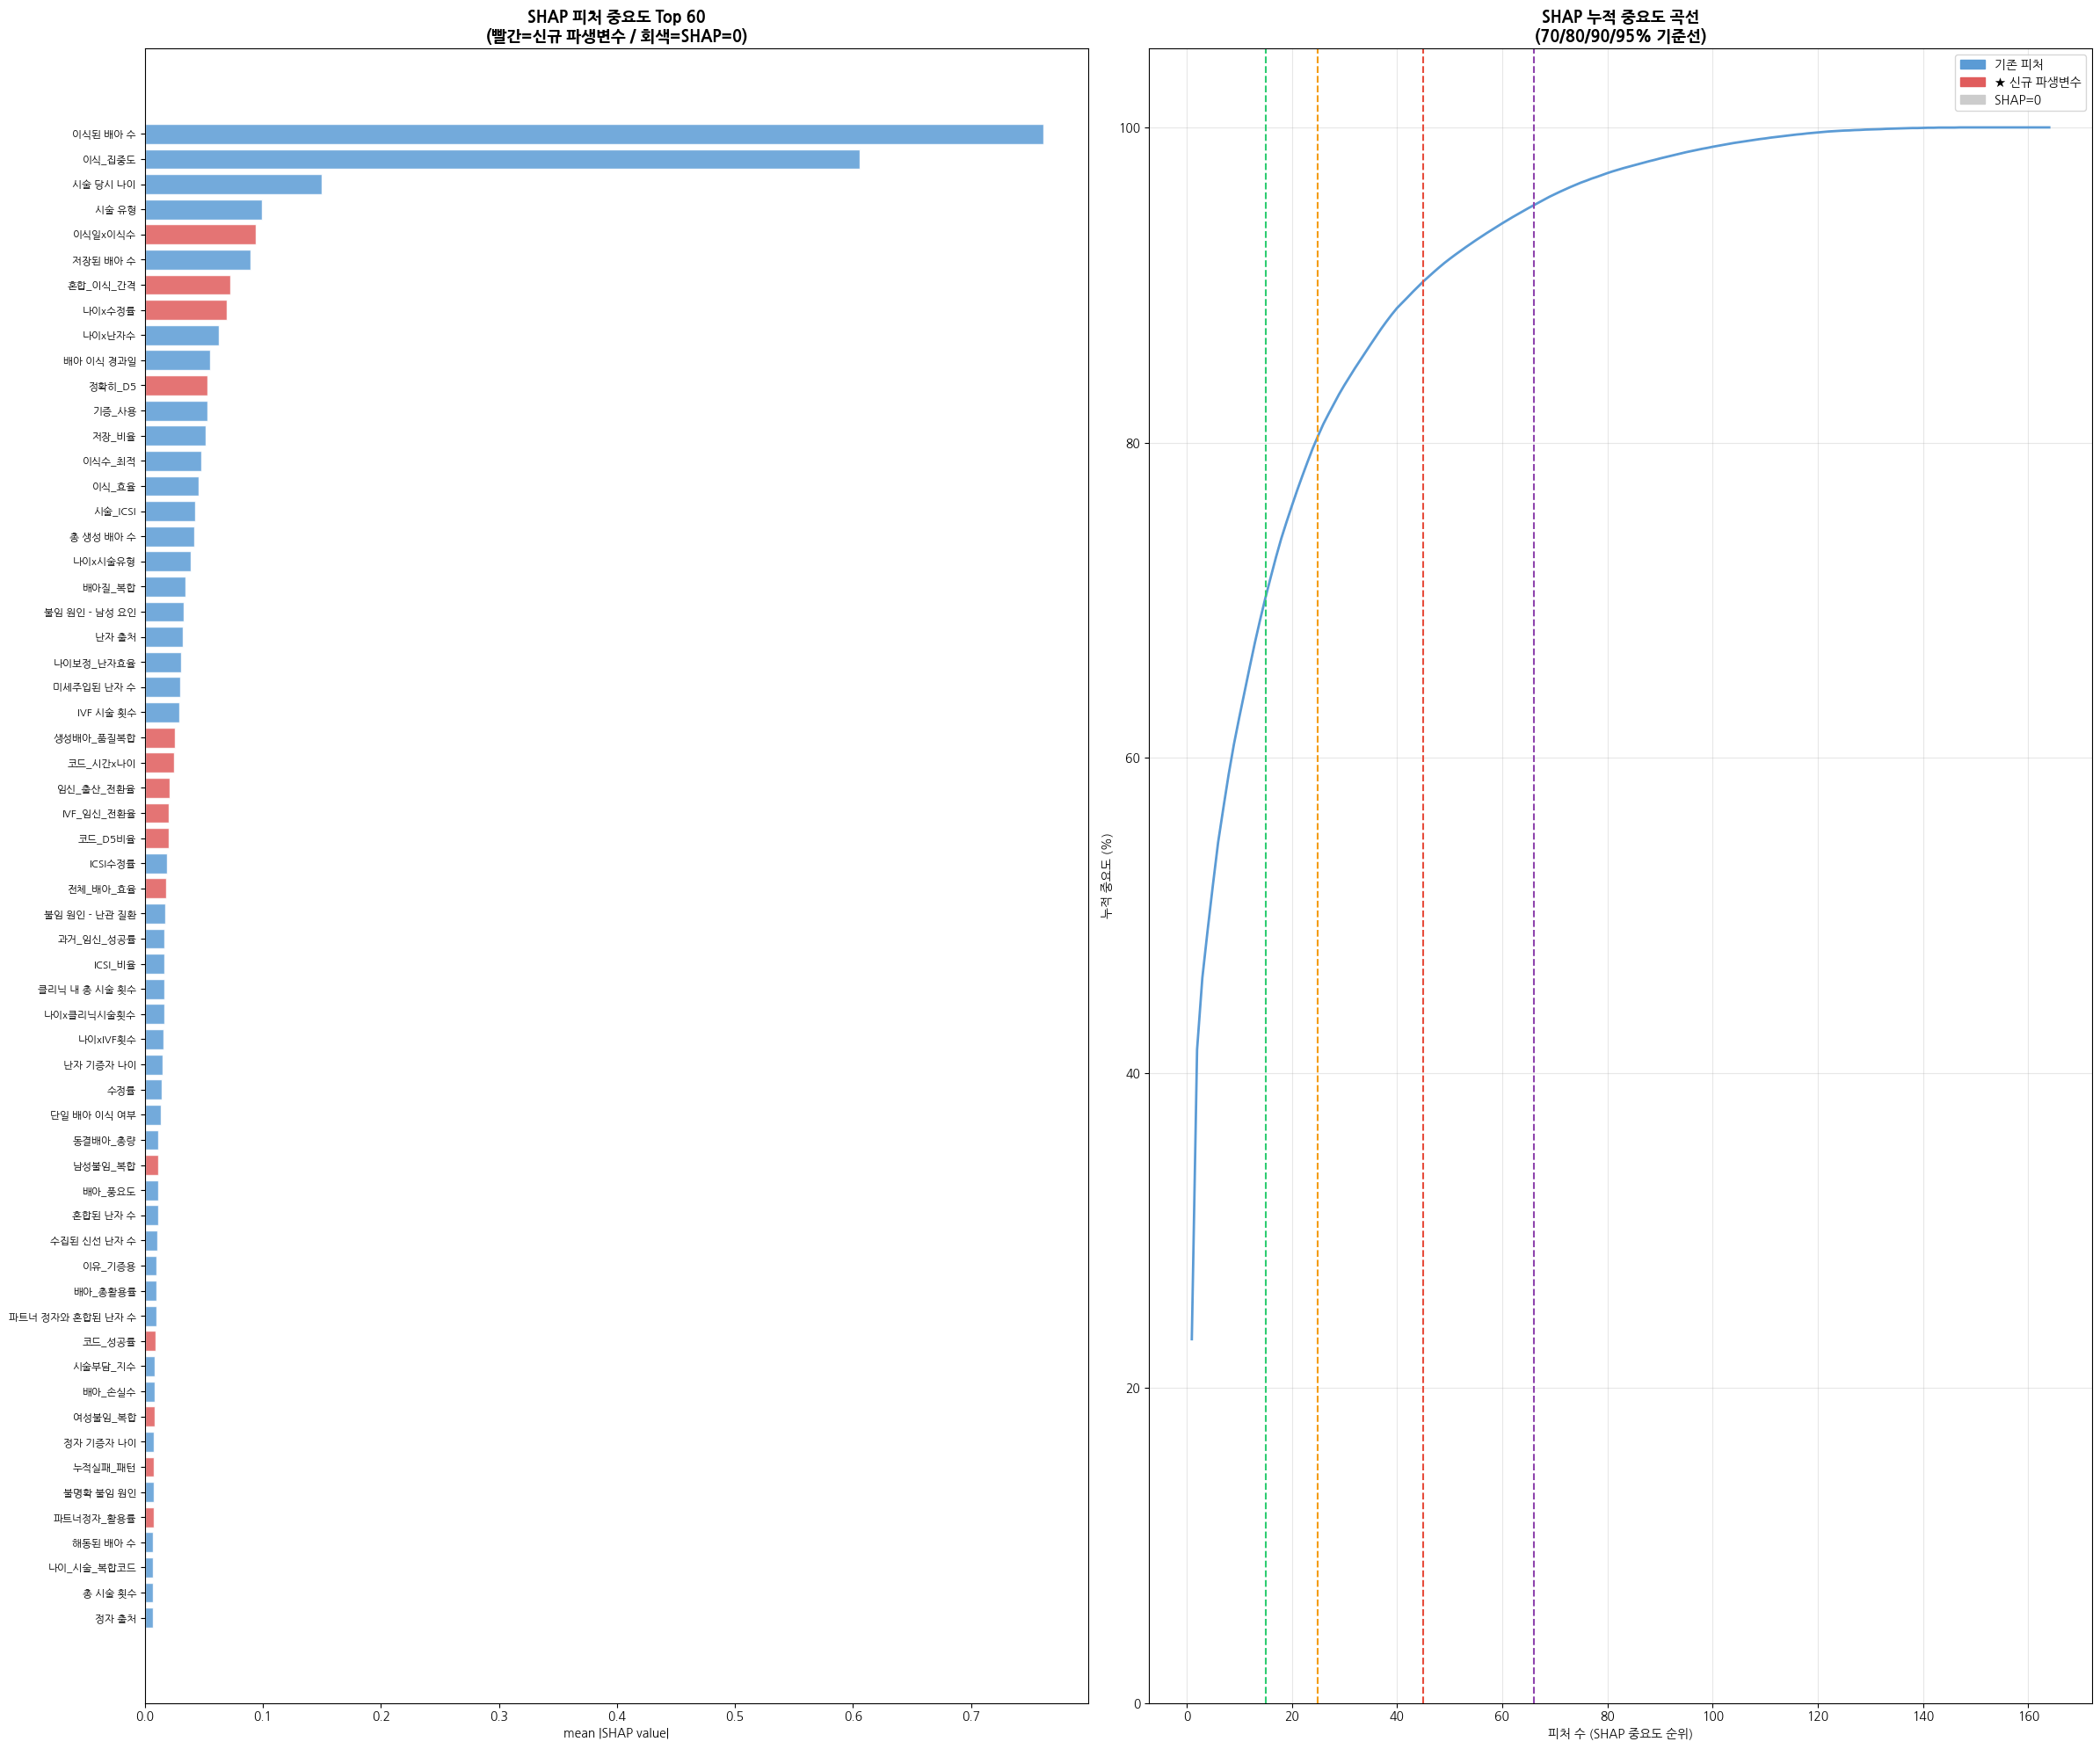

✅ feature_importance_vD2.png 저장

=== SHAP 누적 중요도 기준 Top N 참고 ===
  누적 70%  →  Top 15개 피처
  누적 80%  →  Top 25개 피처
  누적 90%  →  Top 45개 피처
  누적 95%  →  Top 66개 피처

SHAP summary plot 생성 중...


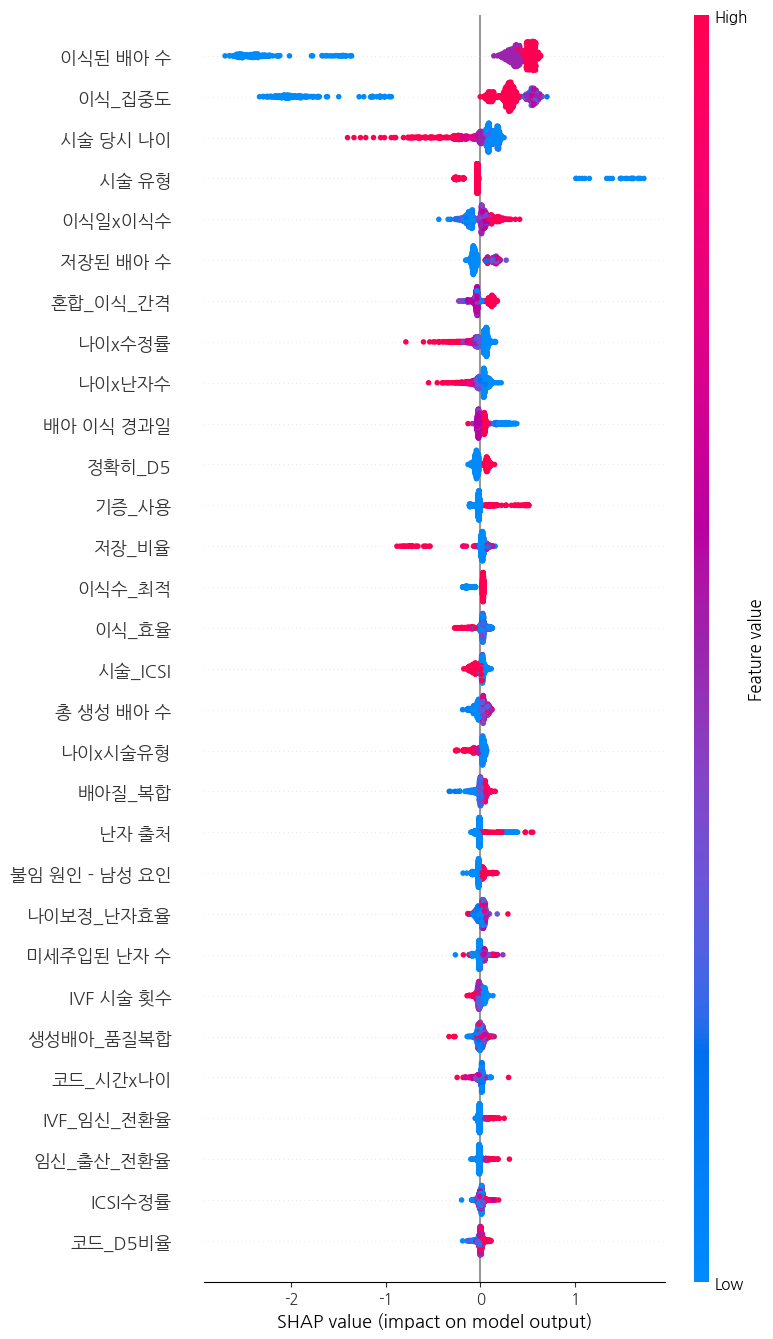

✅ shap_summary_vD2.png 저장


In [15]:
NEW_FEATS = {
    "혼합_이식_간격","이식일_D5이상","이식일x이식수","이식일_결측","정확히_D5","D5_최적이식_복합",
    "생성배아_품질복합","난자_풍부도","신선난자_저장비율","파트너정자_활용률","전체_배아_효율",
    "초회시술","초회IVF","클리닉_집중도","IVF_임신_전환율","임신_출산_전환율","출산_경험","IVF_출산_경험",
    "남성불임_복합","여성불임_복합","복합_불임_여부","나이x불임원인수","나이xD5","나이x수정률","나이x클리닉횟수",
    "난자_채취_결측","배아_해동_결측","임신_시도_연수_결측",
    "코드_D5비율","코드_D3비율","코드_시간순서","코드_성공률","코드_시간x나이",
    "누적실패_패턴","최적_시술_콤보","출산후_재시술","고위험_복합","수정률_D5_복합","IVF_고령_초회",
}

fig, axes = plt.subplots(1, 2, figsize=(24, 20))

# ── 좌: SHAP 중요도 Top60 바차트
top60  = feat_imp.head(60)
colors = []
for f in top60["feature"]:
    if top60[top60["feature"]==f]["shap_imp"].values[0] == 0:
        colors.append("#CCCCCC")
    elif f in NEW_FEATS:
        colors.append("#E05C5C")
    else:
        colors.append("#5B9BD5")

axes[0].barh(top60["feature"][::-1], top60["shap_imp"][::-1],
             color=colors[::-1], alpha=0.85, edgecolor="white")
axes[0].set_title("SHAP 피처 중요도 Top 60\n(빨간=신규 파생변수 / 회색=SHAP=0)",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("mean |SHAP value|")
axes[0].tick_params(axis="y", labelsize=8.5)

# ── 우: 누적 중요도 곡선 (구간별 참고선)
n_all = len(feat_imp)
axes[1].plot(range(1, n_all+1), feat_imp["shap_cumulative"],
             color="#5B9BD5", linewidth=2)
for pct, color in [(70,"#2ECC71"), (80,"#F39C12"), (90,"#E74C3C"), (95,"#8E44AD")]:
    idx = (feat_imp["shap_cumulative"] >= pct).idxmax() + 1
    axes[1].axvline(idx, color=color, linewidth=1.5, linestyle="--",
                    label=f"{pct}% 누적 → Top{idx}개")
axes[1].set_xlabel("피처 수 (SHAP 중요도 순위)")
axes[1].set_ylabel("누적 중요도 (%)")
axes[1].set_title("SHAP 누적 중요도 곡선\n(70/80/90/95% 기준선)", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 105)

plt.legend(handles=[
    mpatches.Patch(color="#5B9BD5", label="기존 피처"),
    mpatches.Patch(color="#E05C5C", label="★ 신규 파생변수"),
    mpatches.Patch(color="#CCCCCC", label="SHAP=0"),
], fontsize=10)
plt.tight_layout()
plt.savefig("feature_importance_vD2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ feature_importance_vD2.png 저장")

# ── 70/80/90/95% 누적 기준 Top N 출력 (다음 버전 TOP_N 결정용)
print("\n=== SHAP 누적 중요도 기준 Top N 참고 ===")
for pct in [70, 80, 90, 95]:
    idx = int((feat_imp["shap_cumulative"] >= pct).idxmax()) + 1
    print(f"  누적 {pct}%  →  Top {idx}개 피처")

# ── SHAP summary plot (샘플 1000개, 방향성 확인)
print("\nSHAP summary plot 생성 중...")
sample_idx = np.random.choice(len(X_arr_full), min(1000, len(X_arr_full)), replace=False)
shap.summary_plot(
    sv[sample_idx],
    X_arr_full[sample_idx],
    feature_names=list(X_pp.columns),
    max_display=30,
    show=False
)
plt.tight_layout()
plt.savefig("shap_summary_vD2.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ shap_summary_vD2.png 저장")

## 6. ML 모델 — Optuna + Seed 앙상블 (HGB 제외, XGB/CAT/LGB × 3seed = 9모델)

In [8]:
print("\n" + "="*55)
print("  [vD-2] ML 모델 학습 (SHAP>0 전체 피처)")
print("="*55)

USE_GPU    = torch.cuda.is_available()
XGB_DEVICE = "cuda" if USE_GPU else "cpu"
LGB_DEVICE = "gpu"  if USE_GPU else "cpu"
CAT_TASK   = "GPU"  if USE_GPU else "CPU"
DEVICE     = torch.device("cuda" if USE_GPU else "cpu")
BATCH_SIZE = 8192 if USE_GPU else 2048

# XGBoost Optuna
print("\n=== XGBoost Optuna ===")
def xgb_obj(trial):
    p = dict(
        n_estimators     = trial.suggest_int("n_estimators", 500, 3000, step=100),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        max_depth        = trial.suggest_int("max_depth", 4, 9),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-3, 10., log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 10., log=True),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 20),
        gamma            = trial.suggest_float("gamma", 0, 5),
        scale_pos_weight = trial.suggest_float("scale_pos_weight", 1.5, 4.0),
        tree_method="hist", device=XGB_DEVICE, eval_metric="auc",
        early_stopping_rounds=50, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )
    oof = np.zeros(len(X_ml))
    for tr, va in skf.split(X_ml, y_arr):
        m = xgb.XGBClassifier(**p)
        m.fit(X_ml[tr], y_arr[tr], eval_set=[(X_ml[va], y_arr[va])], verbose=False)
        oof[va] = m.predict_proba(X_ml[va])[:, 1]
    return roc_auc_score(y_arr, oof)

if USE_CACHED_PARAMS and CACHED_XGB:
    bp_xgb = CACHED_XGB; print(f"캐시 파라미터 사용")
else:
    s_xgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    s_xgb.optimize(xgb_obj, n_trials=N_OPTUNA, show_progress_bar=True)
    bp_xgb = s_xgb.best_params; print(f"XGB best AUC={s_xgb.best_value:.5f}")

# CatBoost Optuna
print("\n=== CatBoost Optuna ===")
def cat_obj(trial):
    p = dict(
        iterations          = trial.suggest_int("iterations", 500, 3000, step=100),
        learning_rate       = trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        depth               = trial.suggest_int("depth", 4, 10),
        l2_leaf_reg         = trial.suggest_float("l2_leaf_reg", 1., 10.),
        bagging_temperature = trial.suggest_float("bagging_temperature", 0, 2),
        random_strength     = trial.suggest_float("random_strength", 0, 2),
        border_count        = trial.suggest_int("border_count", 32, 255),
        auto_class_weights="Balanced", eval_metric="AUC", task_type=CAT_TASK,
        early_stopping_rounds=50, random_seed=RANDOM_STATE, verbose=0,
    )
    oof = np.zeros(len(X_ml))
    for tr, va in skf.split(X_ml, y_arr):
        m = CatBoostClassifier(**p)
        m.fit(X_ml[tr], y_arr[tr], eval_set=(X_ml[va], y_arr[va]), use_best_model=True)
        oof[va] = m.predict_proba(X_ml[va])[:, 1]
    return roc_auc_score(y_arr, oof)

if USE_CACHED_PARAMS and CACHED_CAT:
    bp_cat = CACHED_CAT; print(f"캐시 파라미터 사용")
else:
    s_cat = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    s_cat.optimize(cat_obj, n_trials=N_OPTUNA, show_progress_bar=True)
    bp_cat = s_cat.best_params; print(f"CAT best AUC={s_cat.best_value:.5f}")

# LightGBM Optuna
print("\n=== LightGBM Optuna ===")
def lgb_obj(trial):
    p = dict(
        n_estimators      = trial.suggest_int("n_estimators", 500, 3000, step=100),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        num_leaves        = trial.suggest_int("num_leaves", 31, 255),
        max_depth         = trial.suggest_int("max_depth", 4, 12),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-3, 10., log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-3, 10., log=True),
        min_child_samples = trial.suggest_int("min_child_samples", 5, 100),
        boosting_type     = trial.suggest_categorical("boosting_type", ["gbdt","dart","goss"]),
        class_weight="balanced", device=LGB_DEVICE,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    )
    oof = np.zeros(len(X_ml))
    for tr, va in skf.split(X_ml, y_arr):
        m = lgb.LGBMClassifier(**p)
        m.fit(X_ml[tr], y_arr[tr], eval_set=[(X_ml[va], y_arr[va])],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)])
        oof[va] = m.predict_proba(X_ml[va])[:, 1]
    return roc_auc_score(y_arr, oof)

if USE_CACHED_PARAMS and CACHED_LGB:
    bp_lgb = CACHED_LGB; print(f"캐시 파라미터 사용")
else:
    s_lgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    s_lgb.optimize(lgb_obj, n_trials=N_OPTUNA, show_progress_bar=True)
    bp_lgb = s_lgb.best_params; print(f"LGB best AUC={s_lgb.best_value:.5f}")

# ML Seed 앙상블 (9모델: XGB×3 + CAT×3 + LGB×3, HGB 제외)
print(f"\n=== ML Seed 앙상블 (9모델, 피처 {len(ml_features)}개) ===")
xgb_fp = {**bp_xgb, "tree_method":"hist", "device":XGB_DEVICE,
           "eval_metric":"auc", "early_stopping_rounds":100,
           "random_state":RANDOM_STATE, "n_jobs":-1, "verbosity":0}
cat_fp = {**bp_cat, "auto_class_weights":"Balanced", "eval_metric":"AUC",
           "task_type":CAT_TASK, "early_stopping_rounds":100,
           "random_seed":RANDOM_STATE, "verbose":0}
lgb_fp = {**bp_lgb, "class_weight":"balanced", "device":LGB_DEVICE, "n_jobs":-1, "verbose":-1}

ml_configs = {
    "XGB_42"  : ("xgb", {**xgb_fp, "random_state":42}),
    "XGB_2024": ("xgb", {**xgb_fp, "random_state":2024}),
    "XGB_777" : ("xgb", {**xgb_fp, "random_state":777}),
    "CAT_42"  : ("cat", {**cat_fp, "random_seed":42}),
    "CAT_2024": ("cat", {**cat_fp, "random_seed":2024}),
    "CAT_777" : ("cat", {**cat_fp, "random_seed":777}),
    "LGB_42"  : ("lgb", {**lgb_fp, "random_state":42}),
    "LGB_2024": ("lgb", {**lgb_fp, "random_state":2024}),
    "LGB_777" : ("lgb", {**lgb_fp, "random_state":777}),
}

oof_ml = {}; pred_ml = {}
for name, (mtype, p) in ml_configs.items():
    oof  = np.zeros(len(X_ml))
    pred = np.zeros(len(X_test_ml))
    for tr, va in skf.split(X_ml, y_arr):
        if mtype == "xgb":
            m = xgb.XGBClassifier(**p)
            m.fit(X_ml[tr], y_arr[tr], eval_set=[(X_ml[va], y_arr[va])], verbose=False)
        elif mtype == "cat":
            m = CatBoostClassifier(**p)
            m.fit(X_ml[tr], y_arr[tr], eval_set=(X_ml[va], y_arr[va]), use_best_model=True)
        else:
            m = lgb.LGBMClassifier(**p)
            m.fit(X_ml[tr], y_arr[tr], eval_set=[(X_ml[va], y_arr[va])],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)])
        oof[va]  = m.predict_proba(X_ml[va])[:, 1]
        pred    += m.predict_proba(X_test_ml)[:, 1] / N_SPLITS
    oof_ml[name]  = oof; pred_ml[name] = pred
    print(f"  {name:<12} OOF AUC={roc_auc_score(y_arr, oof):.5f}")

n_ml = len(ml_configs)  # 9
print(f"ML 앙상블 AUC={roc_auc_score(y_arr, np.mean(list(oof_ml.values()), axis=0)):.5f}")


  [vD-2] ML 모델 학습 (SHAP>0 전체 피처)

=== XGBoost Optuna ===
캐시 파라미터 사용

=== CatBoost Optuna ===
캐시 파라미터 사용

=== LightGBM Optuna ===
캐시 파라미터 사용

=== ML Seed 앙상블 (9모델, 피처 66개) ===
  XGB_42       OOF AUC=0.74002
  XGB_2024     OOF AUC=0.73994
  XGB_777      OOF AUC=0.74006


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


  CAT_42       OOF AUC=0.74003


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


  CAT_2024     OOF AUC=0.73991


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


  CAT_777      OOF AUC=0.73997


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  LGB_42       OOF AUC=0.73946
  LGB_2024     OOF AUC=0.73941
  LGB_777      OOF AUC=0.73943
ML 앙상블 AUC=0.74018


## 7. DL 모델 (TabNet: batch=1024, vbs=128)

In [16]:
BATCH_SIZE = 8192 if USE_GPU else 2048
print(f"Batch size: {BATCH_SIZE}")

class MLP(nn.Module):
    def __init__(self, n_in, hidden=[512,256,128], dropout=0.3):
        super().__init__()
        layers = []; in_d = n_in
        for h in hidden:
            layers += [nn.Linear(in_d,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(-1)

class FTTransformer(nn.Module):
    def __init__(self, n_feat, d=64, heads=4, layers=3, drop=0.1):
        super().__init__()
        self.emb = nn.Linear(n_feat, d)
        enc = nn.TransformerEncoderLayer(d_model=d, nhead=heads, dim_feedforward=d*4,
                                         dropout=drop, batch_first=True)
        self.tf  = nn.TransformerEncoder(enc, num_layers=layers)
        self.cls = nn.Sequential(nn.LayerNorm(d), nn.Linear(d,d//2), nn.ReLU(),
                                  nn.Dropout(drop), nn.Linear(d//2,1))
    def forward(self, x): return self.cls(self.tf(self.emb(x).unsqueeze(1)).squeeze(1)).squeeze(-1)

def train_nn(model, X_tr, y_tr, X_va, y_va, epochs=100, lr=1e-3, patience=15):
    device = next(model.parameters()).device
    pos_w  = torch.tensor([(y_tr==0).sum()/(y_tr==1).sum()], dtype=torch.float32).to(device)
    crit   = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch    = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ds     = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                           torch.tensor(y_tr, dtype=torch.float32))
    dl     = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                        pin_memory=USE_GPU, num_workers=2 if USE_GPU else 0)
    best_auc, best_state, no_imp = 0, None, 0
    X_va_t = torch.tensor(X_va, dtype=torch.float32).to(device)
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        sch.step()
        model.eval()
        with torch.no_grad(): vp = torch.sigmoid(model(X_va_t)).cpu().numpy()
        auc = roc_auc_score(y_va, vp)
        if auc > best_auc:
            best_auc = auc
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience: break
    model.load_state_dict(best_state)
    return model, best_auc

def predict_nn(model, X, batch=8192):
    model.eval(); device = next(model.parameters()).device; preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = torch.tensor(X[i:i+batch], dtype=torch.float32).to(device)
            preds.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.concatenate(preds)

print("DL 모델 클래스 정의 완료")
n_dl = X_dl_raw.shape[1]; oof_dl = {}; pred_dl = {}
print(f"DL 입력 피처: {n_dl}개 (SHAP>0 전체)")

print("=== MLP 학습 ===")
oof_mlp = np.zeros(len(X_dl_raw)); pred_mlp = np.zeros(len(X_test_dl))
for fold, (tr, va) in enumerate(skf.split(X_dl_raw, y_arr), 1):
    X_tr, X_va, X_te, _ = scale_dl(X_dl_raw[tr], X_dl_raw[va], X_test_dl, cont_idx)
    model = MLP(n_dl).to(DEVICE)
    model, best_auc = train_nn(model, X_tr, y_arr[tr], X_va, y_arr[va], epochs=100, patience=15)
    oof_mlp[va] = predict_nn(model, X_va); pred_mlp += predict_nn(model, X_te) / N_SPLITS
    print(f"  Fold {fold} MLP AUC={best_auc:.5f}")
    if USE_GPU: torch.cuda.empty_cache()
oof_dl["MLP"] = oof_mlp; pred_dl["MLP"] = pred_mlp
print(f"MLP OOF AUC={roc_auc_score(y_arr, oof_mlp):.5f}")

print("=== TabNet 학습 (batch=1024, vbs=128) ===")
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    oof_tn = np.zeros(len(X_dl_raw)); pred_tn = np.zeros(len(X_test_dl))
    for fold, (tr, va) in enumerate(skf.split(X_dl_raw, y_arr), 1):
        X_tr, X_va, X_te, sc = scale_dl(X_dl_raw[tr], X_dl_raw[va], X_test_dl, cont_idx)
        clf = TabNetClassifier(
            n_d=32, n_a=32, n_steps=5, gamma=1.3,
            seed=RANDOM_STATE, verbose=0,
            device_name="cuda" if USE_GPU else "cpu",
            optimizer_fn=torch.optim.Adam,
            optimizer_params=dict(lr=2e-3, weight_decay=1e-5),
            momentum=0.02
        )
        clf.fit(X_tr, y_arr[tr], eval_set=[(X_va, y_arr[va])], eval_metric=["auc"],
                max_epochs=200, patience=20,
                batch_size=1024,         # ★ 수정
                virtual_batch_size=128,  # ★ 수정
                weights=1)
        oof_tn[va] = clf.predict_proba(X_va)[:, 1]
        pred_tn   += clf.predict_proba(X_te)[:, 1] / N_SPLITS
        print(f"  Fold {fold} TabNet AUC={roc_auc_score(y_arr[va], oof_tn[va]):.5f}")
        if USE_GPU: torch.cuda.empty_cache()
    oof_dl["TabNet"] = oof_tn; pred_dl["TabNet"] = pred_tn
    print(f"TabNet OOF AUC={roc_auc_score(y_arr, oof_tn):.5f}")
except ImportError:
    print("pytorch-tabnet 미설치 — TabNet 제외")
    oof_dl["TabNet"] = np.zeros(len(X_dl_raw)); pred_dl["TabNet"] = np.zeros(len(X_test_dl))

print("=== FT-Transformer 학습 ===")
oof_ftt = np.zeros(len(X_dl_raw)); pred_ftt = np.zeros(len(X_test_dl))
for fold, (tr, va) in enumerate(skf.split(X_dl_raw, y_arr), 1):
    X_tr, X_va, X_te, _ = scale_dl(X_dl_raw[tr], X_dl_raw[va], X_test_dl, cont_idx)
    model = FTTransformer(n_dl).to(DEVICE)
    model, best_auc = train_nn(model, X_tr, y_arr[tr], X_va, y_arr[va],
                               epochs=80, patience=15, lr=5e-4)
    oof_ftt[va] = predict_nn(model, X_va); pred_ftt += predict_nn(model, X_te) / N_SPLITS
    print(f"  Fold {fold} FTT AUC={best_auc:.5f}")
    if USE_GPU: torch.cuda.empty_cache()
oof_dl["FT_Transformer"] = oof_ftt; pred_dl["FT_Transformer"] = pred_ftt
print(f"FT-Transformer OOF AUC={roc_auc_score(y_arr, oof_ftt):.5f}")

Batch size: 8192
DL 모델 클래스 정의 완료
DL 입력 피처: 66개 (SHAP>0 전체)
=== MLP 학습 ===
  Fold 1 MLP AUC=0.73753
  Fold 2 MLP AUC=0.74245
  Fold 3 MLP AUC=0.74016
  Fold 4 MLP AUC=0.73796
  Fold 5 MLP AUC=0.74041
MLP OOF AUC=0.73962
=== TabNet 학습 (batch=1024, vbs=128) ===

Early stopping occurred at epoch 149 with best_epoch = 129 and best_val_0_auc = 0.73553
  Fold 1 TabNet AUC=0.73553

Early stopping occurred at epoch 107 with best_epoch = 87 and best_val_0_auc = 0.74
  Fold 2 TabNet AUC=0.74000

Early stopping occurred at epoch 118 with best_epoch = 98 and best_val_0_auc = 0.73802
  Fold 3 TabNet AUC=0.73802

Early stopping occurred at epoch 49 with best_epoch = 29 and best_val_0_auc = 0.73056
  Fold 4 TabNet AUC=0.73056

Early stopping occurred at epoch 115 with best_epoch = 95 and best_val_0_auc = 0.73747
  Fold 5 TabNet AUC=0.73747
TabNet OOF AUC=0.73610
=== FT-Transformer 학습 ===
  Fold 1 FTT AUC=0.73730
  Fold 2 FTT AUC=0.74221
  Fold 3 FTT AUC=0.74005
  Fold 4 FTT AUC=0.73794
  Fold 5 FTT AU

## 8. 2단계 스태킹 앙상블

In [17]:
print("=== [vD-2] 2단계 스태킹 ===")

all_oof  = {**oof_ml, **oof_dl}
all_pred = {**pred_ml, **pred_dl}
n_models = len(all_oof)
print(f"Level 0 모델: {list(all_oof.keys())}")

meta_train_base = np.column_stack(list(all_oof.values()))
meta_test_base  = np.column_stack(list(all_pred.values()))
ml_idx = list(range(n_ml))
dl_idx = list(range(n_ml, n_models))

def build_meta(mat, ml_idx, dl_idx):
    ml_m = mat[:, ml_idx].mean(axis=1, keepdims=True)
    dl_m = mat[:, dl_idx].mean(axis=1, keepdims=True) if dl_idx else np.zeros((len(mat), 1))
    return np.hstack([mat, ml_m, dl_m,
                      mat.std(axis=1, keepdims=True),
                      mat[:, ml_idx].std(axis=1, keepdims=True),
                      ml_m - dl_m])

meta_train = build_meta(meta_train_base, ml_idx, dl_idx)
meta_test  = build_meta(meta_test_base,  ml_idx, dl_idx)
print(f"메타 피처: {meta_train.shape[1]}개")

mp = dict(n_estimators=500, learning_rate=0.02, num_leaves=15, max_depth=4,
          subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
          class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

oof_mlgb = np.zeros(len(meta_train)); pred_mlgb = np.zeros(len(meta_test))
for tr, va in skf.split(meta_train, y_arr):
    m = lgb.LGBMClassifier(**mp)
    m.fit(meta_train[tr], y_arr[tr], eval_set=[(meta_train[va], y_arr[va])],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)])
    oof_mlgb[va]  = m.predict_proba(meta_train[va])[:, 1]
    pred_mlgb    += m.predict_proba(meta_test)[:, 1] / N_SPLITS
print(f"Meta-LGB OOF AUC={roc_auc_score(y_arr, oof_mlgb):.5f}")

oof_mlr = np.zeros(len(meta_train)); pred_mlr = np.zeros(len(meta_test))
for tr, va in skf.split(meta_train, y_arr):
    sc  = StandardScaler()
    mtr = sc.fit_transform(meta_train[tr])
    mva = sc.transform(meta_train[va])
    mte = sc.transform(meta_test)
    lr  = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")
    lr.fit(mtr, y_arr[tr])
    oof_mlr[va]  = lr.predict_proba(mva)[:, 1]
    pred_mlr    += lr.predict_proba(mte)[:, 1] / N_SPLITS
print(f"Meta-LR  OOF AUC={roc_auc_score(y_arr, oof_mlr):.5f}")

def neg_auc(w):
    w = np.array(w); w = w / w.sum()
    return -roc_auc_score(y_arr, w[0]*oof_mlgb + w[1]*oof_mlr)

res   = minimize(neg_auc, x0=[0.7,0.3], bounds=[(0,1)]*2, method="L-BFGS-B")
w_f   = np.array(res.x) / np.array(res.x).sum()
oof_final  = w_f[0]*oof_mlgb  + w_f[1]*oof_mlr
pred_final = w_f[0]*pred_mlgb + w_f[1]*pred_mlr
print(f"\n[vD-2] 최종 OOF AUC={roc_auc_score(y_arr, oof_final):.5f}")
print(f"Meta-LGB={w_f[0]:.3f}, Meta-LR={w_f[1]:.3f}")

=== [vD-2] 2단계 스태킹 ===
Level 0 모델: ['XGB_42', 'XGB_2024', 'XGB_777', 'CAT_42', 'CAT_2024', 'CAT_777', 'LGB_42', 'LGB_2024', 'LGB_777', 'MLP', 'TabNet', 'FT_Transformer']
메타 피처: 17개
Meta-LGB OOF AUC=0.74011
Meta-LR  OOF AUC=0.73949

[vD-2] 최종 OOF AUC=0.74026
Meta-LGB=0.700, Meta-LR=0.300


## 9. 결과 요약 & 제출 파일

In [18]:
print("="*60)
print("  [vD-2] 성능 비교  (SHAP 전체 피처 / TabNet 수정)")
print("="*60)
results = {
    "베이스라인 (v5)":   0.74058,
    "ML 앙상블 (9모델)": roc_auc_score(y_arr, np.mean(list(oof_ml.values()), axis=0)),
    "스태킹 최종":       roc_auc_score(y_arr, oof_final),
}
for name, oof in oof_dl.items():
    if oof.sum() != 0:
        results[f"DL {name}"] = roc_auc_score(y_arr, oof)

for k, v in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar    = "█" * int((v - 0.72) * 500)
    marker = " ★" if k=="스태킹 최종" else ("  ↑베이스" if "베이스" in k else "")
    print(f"  {k:<34} {v:.5f}  {bar}{marker}")
print("="*60)

# 다음 버전 TOP_N 결정 가이드
print("\n=== 다음 버전 TOP_N 가이드 (SHAP 기준) ===")
for pct in [70, 80, 90, 95]:
    idx = int((feat_imp["shap_cumulative"] >= pct).idxmax()) + 1
    print(f"  누적 {pct}%  →  Top {idx}개")

sub_final = sub.copy(); sub_final["probability"] = pred_final
sub_final.to_csv("submission_vD2_final.csv", index=False)
print("\n✅ submission_vD2_final.csv 저장 완료")

sub_ml = sub.copy(); sub_ml["probability"] = np.mean(list(pred_ml.values()), axis=0)
sub_ml.to_csv("submission_vD2_ml_only.csv", index=False)
print("✅ submission_vD2_ml_only.csv 저장 완료")
print(sub_final.head())

  [vD-2] 성능 비교  (SHAP 전체 피처 / TabNet 수정)
  베이스라인 (v5)                         0.74058  ██████████  ↑베이스
  스태킹 최종                             0.74026  ██████████ ★
  ML 앙상블 (9모델)                       0.74018  ██████████
  DL MLP                             0.73962  █████████
  DL FT_Transformer                  0.73923  █████████
  DL TabNet                          0.73610  ████████

=== 다음 버전 TOP_N 가이드 (SHAP 기준) ===
  누적 70%  →  Top 15개
  누적 80%  →  Top 25개
  누적 90%  →  Top 45개
  누적 95%  →  Top 66개

✅ submission_vD2_final.csv 저장 완료
✅ submission_vD2_ml_only.csv 저장 완료
           ID  probability
0  TEST_00000     0.013773
1  TEST_00001     0.048463
2  TEST_00002     0.315957
3  TEST_00003     0.240086
4  TEST_00004     0.750721
